# Dota 2 Hero Browser

- browse and visualize Dota 2 heroes with images and some stats for now

## Features
* View all heroes by their main attribute (Strength, Agility, Intelligence)
* Display hero images with proper color rendering (still in works)
* Browse heroes by role

In [0]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import base64
import io
from urllib.request import urlopen, Request
from PIL import Image

In [0]:

def get_steam_hero_url(hero_name):
    hero_slug = hero_name.lower().replace("'", "").replace("-", "").replace(" ", "_")
    
    special_cases = {
        "natures_prophet": "furion", "wraith_king": "skeleton_king", "timbersaw": "shredder",
        "clockwerk": "rattletrap", "outworld_destroyer": "obsidian_destroyer", "necrophos": "necrolyte",
        "windranger": "windrunner", "zeus": "zuus", "underlord": "abyssal_underlord",
        "anti_mage": "antimage", "lifestealer": "life_stealer", "doom": "doom_bringer",
        "treant_protector": "treant", "centaur_warrunner": "centaur"
    }
    
    if hero_slug in special_cases:
        hero_slug = special_cases[hero_slug]
    
    return f"https://cdn.cloudflare.steamstatic.com/apps/dota2/images/dota_react/heroes/{hero_slug}.png"

def display_hero_image_steam(hero_name, heroes_df):
    hero = heroes_df.filter(F.col("name") == hero_name).first()
    if not hero:
        print(f"Hero '{hero_name}' not found")
        return
    
    try:
        img_url = get_steam_hero_url(hero.name)
        req = Request(img_url, headers={'User-Agent': 'Mozilla/5.0'})
        response = urlopen(req)
        img_data = response.read()
        
        img = Image.open(io.BytesIO(img_data))
        
        if img.mode in ('RGBA', 'LA', 'P'):
                background = Image.new('RGB', img.size, (255, 255, 255))
                if img.mode == 'P':
                    img = img.convert('RGBA')
                background.paste(img, mask=img.split()[-1] if img.mode == 'RGBA' else None)
                img = background
        elif img.mode != 'RGB':
            img = img.convert('RGB')
        
        r, g, b = img.split()
        img = Image.merge('RGB', (b, g, r))
        
        buffer = io.BytesIO()
        img.save(buffer, format='JPEG', quality=95)
        img_base64 = base64.b64encode(buffer.getvalue()).decode('utf-8')
        
        html = f"""
        <div style="text-align: center; padding: 20px; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); border-radius: 10px;">
            <h3 style="color: white; text-shadow: 2px 2px 4px rgba(0,0,0,0.5);">{hero.name}</h3>
            <img src="data:image/jpeg;base64,{img_base64}" width="256" style="border: 3px solid white; border-radius: 5px; box-shadow: 0 4px 6px rgba(0,0,0,0.3);">
            <p style="color: white; font-weight: bold; margin-top: 10px;"><b>Primary Attribute:</b> {hero.primary_attr.upper()}</p>
            <p style="color: white;"><b>Roles:</b> {hero.roles}</p>
        </div>
        """
        displayHTML(html)
        print(f"✓ Successfully loaded {hero.name}")
    except Exception as e:
        print(f"Error loading {hero_name}: {e}")

def display_hero_grid_steam(hero_names, heroes_df, limit=12):
    if hero_names:
        heroes = heroes_df.filter(F.col("name").isin(hero_names)).collect()
    else:
        heroes = heroes_df.limit(limit).collect()
    
    html = '<div style="display: flex; flex-wrap: wrap; gap: 15px; justify-content: center;">' 
    
    for hero in heroes:
        try:
            img_url = get_steam_hero_url(hero.name)
            req = Request(img_url, headers={'User-Agent': 'Mozilla/5.0'})
            response = urlopen(req)
            img_data = response.read()
            
            img = Image.open(io.BytesIO(img_data))
            
            if img.mode in ('RGBA', 'LA', 'P'):
                background = Image.new('RGB', img.size, (255, 255, 255))
                if img.mode == 'P':
                    img = img.convert('RGBA')
                background.paste(img, mask=img.split()[-1] if img.mode == 'RGBA' else None)
                img = background
            elif img.mode != 'RGB':
                img = img.convert('RGB')
            
            r, g, b = img.split()
            img = Image.merge('RGB', (b, g, r))
            
            buffer = io.BytesIO()
            img.save(buffer, format='JPEG', quality=95)
            img_base64 = base64.b64encode(buffer.getvalue()).decode('utf-8')
            
            html += f"""
            <div style="border: 3px solid #333; padding: 12px; text-align: center; width: 200px; 
                        background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); border-radius: 8px;
                        box-shadow: 0 4px 8px rgba(0,0,0,0.3);">
                <img src="data:image/jpeg;base64,{img_base64}" width="150" style="border-radius: 5px; border: 2px solid white;">
                <h4 style="margin: 8px 0; color: white; text-shadow: 1px 1px 2px rgba(0,0,0,0.5);">{hero.name}</h4>
                <p style="font-size: 13px; color: #ffd700; margin: 4px 0; font-weight: bold;">{hero.primary_attr.upper()}</p>
                <p style="font-size: 11px; color: #ddd; margin: 0;">{hero.roles}</p>
            </div>
            """
        except Exception as e:
            print(f"Failed to load {hero.name}: {e}")
    
    html += '</div>'
    displayHTML(html)

In [0]:
heroes_df = spark.table("dota_heroes")

print(f"Loaded {heroes_df.count()} heroes")
print("\nHero Attributes:")
heroes_df.groupBy("primary_attr").count().show()

Loaded 127 heroes

Hero Attributes:
+------------+-----+
|primary_attr|count|
+------------+-----+
|         agi|   35|
|         str|   36|
|         all|   22|
|         int|   34|
+------------+-----+



In [0]:
# # strength heroes
# str_heroes = [row.name for row in heroes_df.filter(F.col("primary_attr") == "str").select("name").collect()]

# print(f"Found {len(str_heroes)} Strength heroes\n")
# display_hero_grid_steam(str_heroes, heroes_df)

Found 72 Carry heroes

Failed to load Shadow Fiend: HTTP Error 404: Not Found


Anti-Mage 
 AGI 
 Carry, Escape, Nuker 
 
 
 
 
 Axe 
 STR 
 Initiator, Durable, Disabler, Carry 
 
 
 
 
 Bloodseeker 
 AGI 
 Carry, Disabler, Nuker, Initiator 
 
 
 
 
 Drow Ranger 
 AGI 
 Carry, Disabler, Pusher 
 
 
 
 
 Juggernaut 
 AGI 
 Carry, Pusher, Escape 
 
 
 
 
 Mirana 
 AGI 
 Carry, Support, Escape, Nuker, Disabler 
 
 
 
 
 Morphling 
 AGI 
 Carry, Escape, Durable, Nuker, Disabler 
 
 
 
 
 Phantom Lancer 
 AGI 
 Carry, Escape, Pusher, Nuker 
 
 
 
 
 Razor 
 AGI 
 Carry, Durable, Nuker, Pusher 
 
 
 
 
 Storm Spirit 
 INT 
 Carry, Escape, Nuker, Initiator, Disabler 
 
 
 
 
 Sven 
 STR 
 Carry, Disabler, Initiator, Durable, Nuker
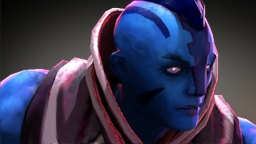
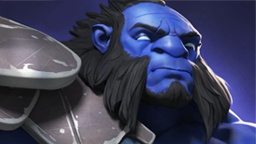
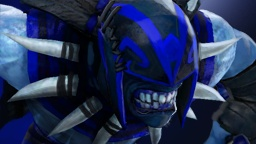
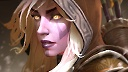
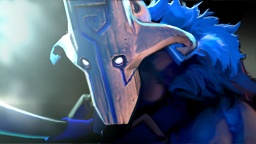
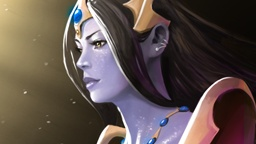
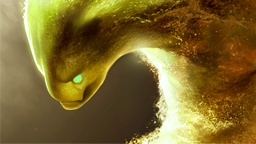
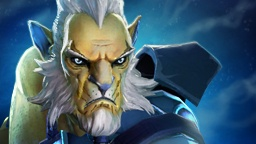
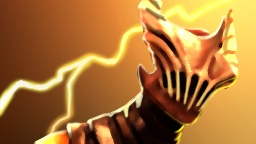
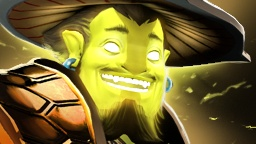
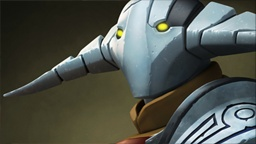

In [0]:
# Find heroes by role ("Carry", "Support", "Nuker")

role = "Carry"

carry_heroes = [
    row.name 
    for row in heroes_df.filter(F.col("roles").contains(role)).select("name").collect()
]

print(f"Found {len(carry_heroes)} {role} heroes\n")
display_hero_grid_steam(carry_heroes[:12], heroes_df) 

Heroes matching 'Phantom':

  • Phantom Lancer
  • Phantom Assassin



Phantom Lancer 
 AGI 
 Carry, Escape, Pusher, Nuker 
 
 
 
 
 Phantom Assassin 
 AGI 
 Carry, Escape
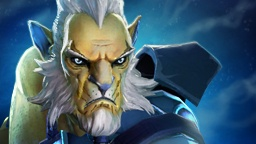
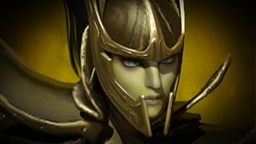

In [0]:
search_term = "Phantom"

matching_heroes = [
    row.name 
    for row in heroes_df.filter(F.col("name").contains(search_term)).select("name").collect()
]

print(f"Heroes matching '{search_term}':\n")
for hero in matching_heroes:
    print(f"  • {hero}")

if matching_heroes:
    print()
    display_hero_grid_steam(matching_heroes, heroes_df)